In [2]:
import numpy as np
import sympy as sp

sp.init_printing()

# ------------------------------------------------------------
# Symboler
# ------------------------------------------------------------

s, t = sp.symbols("s t", real=True)

omega_n, omega_d, zeta, Q = sp.symbols(
    r"\omega_n \omega_d \zeta Q",
    real=True,
    positive=True
)

a_1, a_0, b_0, b_1, b_2 = sp.symbols(
    r"a_1 a_0 b_0 b_1 b_2",
    real=True
)

PO_sym = sp.Symbol("PO")
t_p = sp.Symbol("t_p")
t_s = sp.Symbol("t_s")
theta = sp.Symbol(r"\theta")
theta_deg = sp.Symbol(r"\theta_{\mathrm{deg}}")

p_1, p_2 = sp.symbols("p_1 p_2")

x = sp.Function("x")
y = sp.Function("y")
H = sp.Function("H")

def nice_value(val, digits=4):
    """Pæn numerisk værdi til sympy-display."""
    if val is None:
        return None
    if isinstance(val, complex) or np.iscomplexobj(val):
        return sp.N(val.real, digits) + sp.N(val.imag, digits) * sp.I
    return sp.N(val, digits)


def display_eq(lhs, rhs, digits=4):
    """Viser en pæn ligning."""
    display(sp.Eq(lhs, nice_value(rhs, digits)))


def second_order_tools(
    PO=None,
    tp=None,
    zeta_val=None,
    wn=None,
    wd=None,
    Q_val=None,
    a1=None,
    a0=None,
    dc_gain=None,
    final_value=None,
    numerator_type="lowpass",
    digits=4
):
    """
    2. ordens system helper.

    Eksempler:
    second_order_tools(PO=45.59, tp=0.785, final_value=2)
    second_order_tools(a1=2, a0=17, final_value=2)
    second_order_tools(zeta_val=0.24, wn=4.12)
    second_order_tools(a1=5, a0=4, numerator_type="unknown")

    Antager standardnævner:
        s^2 + a1*s + a0 = s^2 + 2*zeta*wn*s + wn^2

    PO, tp og ts er standardformler for underdæmpet 2. ordens lowpass uden nulpunkter.
    """

    notes = []

    # ------------------------------------------------------------
    # Grundlæggende sammenhænge
    # ------------------------------------------------------------

    if wn is None and a0 is not None:
        wn = np.sqrt(a0)

    if zeta_val is None and Q_val is not None:
        zeta_val = 1 / (2 * Q_val)

    if Q_val is None and zeta_val is not None:
        Q_val = 1 / (2 * zeta_val)

    if zeta_val is None and a1 is not None and wn is not None:
        zeta_val = a1 / (2 * wn)

    # Fra overshoot
    if zeta_val is None and PO is not None:
        if PO <= 0:
            notes.append("PO <= 0: kan ikke finde zeta fra overshoot-formlen.")
        else:
            A = np.log(PO / 100)
            zeta_val = abs(A) / np.sqrt(np.pi**2 + A**2)
            Q_val = 1 / (2 * zeta_val)

    # Fra peak time
    if wd is None and tp is not None:
        wd = np.pi / tp

    if wn is None and wd is not None and zeta_val is not None:
        if zeta_val < 1:
            wn = wd / np.sqrt(1 - zeta_val**2)
        else:
            notes.append("zeta >= 1: tp/wd-formlen passer ikke, fordi systemet ikke oscillerer.")

    if wd is None and wn is not None and zeta_val is not None:
        if zeta_val < 1:
            wd = wn * np.sqrt(1 - zeta_val**2)
        else:
            notes.append("zeta >= 1: ingen dæmpet egenfrekvens omega_d.")

    if a1 is None and zeta_val is not None and wn is not None:
        a1 = 2 * zeta_val * wn

    if a0 is None and wn is not None:
        a0 = wn**2

    if Q_val is None and zeta_val is not None:
        Q_val = 1 / (2 * zeta_val)

    # ------------------------------------------------------------
    # Afledte størrelser
    # ------------------------------------------------------------

    PO_calc = None
    tp_calc = None
    ts_calc = None
    theta_rad = None
    theta_deg_val = None
    poles = None
    damping_type = None

    if zeta_val is not None:
        if zeta_val < 1:
            damping_type = "underdamped"
            PO_calc = 100 * np.exp(-zeta_val * np.pi / np.sqrt(1 - zeta_val**2))
            theta_rad = np.arccos(zeta_val)
            theta_deg_val = np.rad2deg(theta_rad)
        elif np.isclose(zeta_val, 1):
            damping_type = "critically damped"
        else:
            damping_type = "overdamped"

    if wd is not None and wd != 0:
        tp_calc = np.pi / wd

    if zeta_val is not None and wn is not None and zeta_val > 0:
        ts_calc = 4 / (zeta_val * wn)  # 2%-regel

    if zeta_val is not None and wn is not None:
        if zeta_val < 1:
            poles = (
                -zeta_val * wn + 1j * wn * np.sqrt(1 - zeta_val**2),
                -zeta_val * wn - 1j * wn * np.sqrt(1 - zeta_val**2)
            )
        elif np.isclose(zeta_val, 1):
            poles = (-wn, -wn)
        else:
            p_pos = -zeta_val * wn + wn * np.sqrt(zeta_val**2 - 1)
            p_neg = -zeta_val * wn - wn * np.sqrt(zeta_val**2 - 1)
            poles = (p_pos, p_neg)

    # ------------------------------------------------------------
    # Lowpass-tæller b0
    # ------------------------------------------------------------

    b0_val = None

    if numerator_type == "lowpass":
        gain = dc_gain if dc_gain is not None else final_value

        if gain is not None and a0 is not None:
            b0_val = gain * a0
    else:
        notes.append("Tæller antages ikke lowpass. Derfor beregnes b0 ikke fra final_value/dc_gain.")

    # ------------------------------------------------------------
    # Pænt output
    # ------------------------------------------------------------

    display(sp.Symbol(r"\text{2. ordens system}"))

    if damping_type is not None:
        display(sp.Eq(sp.Symbol(r"\text{type}"), sp.Symbol(rf"\text{{{damping_type}}}")))

    # Numeriske værdier med rigtige symboler
    eqs = [
        (zeta, zeta_val),
        (Q, Q_val),
        (omega_n, wn),
        (omega_d, wd),
        (a_1, a1),
        (a_0, a0),
        (PO_sym, PO_calc),
        (t_p, tp_calc),
        (t_s, ts_calc),
        (theta_deg, theta_deg_val),
        (theta, theta_rad),
        (b_0, b0_val),
    ]

    for lhs, rhs in eqs:
        if rhs is not None:
            display_eq(lhs, rhs, digits)

    if poles is not None:
        display_eq(p_1, poles[0], digits)
        display_eq(p_2, poles[1], digits)

    # ------------------------------------------------------------
    # Symbolske standardformer
    # ------------------------------------------------------------

    display(sp.Eq(sp.Symbol("Q(s)"), s**2 + a_1*s + a_0))

    display(
        sp.Eq(
            sp.Symbol("Q(s)"),
            s**2 + 2*zeta*omega_n*s + omega_n**2
        )
    )

    if a1 is not None and a0 is not None:
        den_expr = s**2 + nice_value(a1, digits) * s + nice_value(a0, digits)
        display(sp.Eq(sp.Symbol("Q(s)"), den_expr))

    # ------------------------------------------------------------
    # Transferfunktion og ODE hvis lowpass b0 er kendt
    # ------------------------------------------------------------

    if b0_val is not None and a1 is not None and a0 is not None:
        H_expr = nice_value(b0_val, digits) / den_expr

        display(sp.Eq(H(s), H_expr))

        ode_expr = sp.Eq(
            sp.diff(y(t), t, 2)
            + nice_value(a1, digits) * sp.diff(y(t), t)
            + nice_value(a0, digits) * y(t),
            nice_value(b0_val, digits) * x(t)
        )

        display(ode_expr)

    # ------------------------------------------------------------
    # Hvis kun nævneren er bestemt
    # ------------------------------------------------------------

    elif a1 is not None and a0 is not None:
        display(sp.Symbol(r"\text{Kun nævneren er bestemt. Tælleren afhænger af filtertype.}"))

        display(sp.Eq(H(s), b_0 / den_expr))
        display(sp.Eq(H(s), b_1*s / den_expr))
        display(sp.Eq(H(s), b_2*s**2 / den_expr))

    # ------------------------------------------------------------
    # Noter
    # ------------------------------------------------------------

    if notes:
        for note in notes:
            display(sp.Symbol(rf"\text{{Note: {note}}}"))

    return {
        "zeta": zeta_val,
        "Q": Q_val,
        "wn": wn,
        "wd": wd,
        "a1": a1,
        "a0": a0,
        "PO": PO_calc,
        "tp": tp_calc,
        "ts": ts_calc,
        "theta_deg": theta_deg_val,
        "theta_rad": theta_rad,
        "poles": poles,
        "b0": b0_val,
        "damping_type": damping_type,
        "notes": notes,
    }

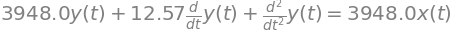

In [ ]:
# ------------------------------------------------------------
# 2nd order helper
# ------------------------------------------------------------
# Nævneren s^2 + a1*s + a0 giver altid:
# omega_n, zeta, Q, omega_d, poler.
#
# Steprespons-formler som PO, tp og ts antager standard 2. ordens LOWPASS:
# H(s) = b0 / (s^2 + a1*s + a0)
# altså ingen s-led eller nulpunkter i tælleren.
#
# Hvis H(s) har tæller som s, s^2 eller ekstra nulpunkter,
# fx highpass/bandpass, kan scriptet stadig bruges til poler og damping,
# men PO, tp, ts og final_value må ikke bruges blindt.
#
# final_value/dc_gain bruges kun til at finde b0, hvis vi antager lowpass:
# b0 = dc_gain * a0

#test eksempler
res = second_order_tools(PO=72.92, tp=0.05025, final_value=1)
#res = second_order_tools(zeta_val=0.4, wn=4, numerator_type="unknown")